# Analysis of Control / Random nodes (in progress)

1. Consider those nodes as CONTROL NODES which have
    
    A. High degree but low median time
    
    B. Low degree but high median time
   
2. Control nodes are (251,38),(71,284),(1,214),(149,362)
3. RANDOM NODES are (105,318),(13,226),(65,278),(48,261),(324,111),(62,275)
    - (62,275) shows 94 transitions. This pair came from node probability analysis
5. Plot parameters for both control and random nodes
6. Plot TOE for control nodes

- To do
  1. TOE for random nodes
  2. Can add to random nodes from 'random' folder on deciding which node to add

In [10]:
%reload_ext autoreload
%autoreload 2

import networkx as nx
import numpy as np
import pandas as pd
from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
from matplotlib import cm
from matplotlib.colors import TwoSlopeNorm
import matplotlib.pyplot as plt
from pathlib import Path
import glob
import seaborn as sns
import matplotlib.pyplot as plt
from tes.DataUtils import DataUtils

#### Finding out degree using functionin DataUtils

In [11]:
l = DataUtils()
analyse = AnalysisFunc()
reader = DataRead()

../../data/connectivity_matrix/mb_communities.npz already exists
DataUtils initialized


In [12]:
df_nc = reader.data_read_bz2("raw/FN/nc_200.bz2")

df_itr = reader.data_read_bz2("raw/FN/itr_200.bz2")

# Graph of whole brain conn. matrix


In [13]:
# here G is the undirected graph
G = nx.from_numpy_array(l.WHOLE_BRAIN_CONN)

## Checking if whole brain conn matrix is symmetric or unsymmetric

In [6]:
type(l.WHOLE_BRAIN_CONN)
f = l.WHOLE_BRAIN_CONN
f_T = l.WHOLE_BRAIN_CONN.T

In [7]:
f[36, 213]

0.0016204648885519857

In [8]:
f_T[213, 36]

0.0016204648885519857

In [9]:
if f.all() == f_T.all():
    print("True")

True


It is a symmetric matrix

# Random nodes 
 1. 105,318
 2. 13,226
 3. 65,278
 4. 48,261
 5. 324,111
 6. 62,275

In [14]:
random_nodes = [105, 318, 13, 226, 65, 278, 48, 261, 324, 111, 62, 275]

(1300.0, 2000.0)

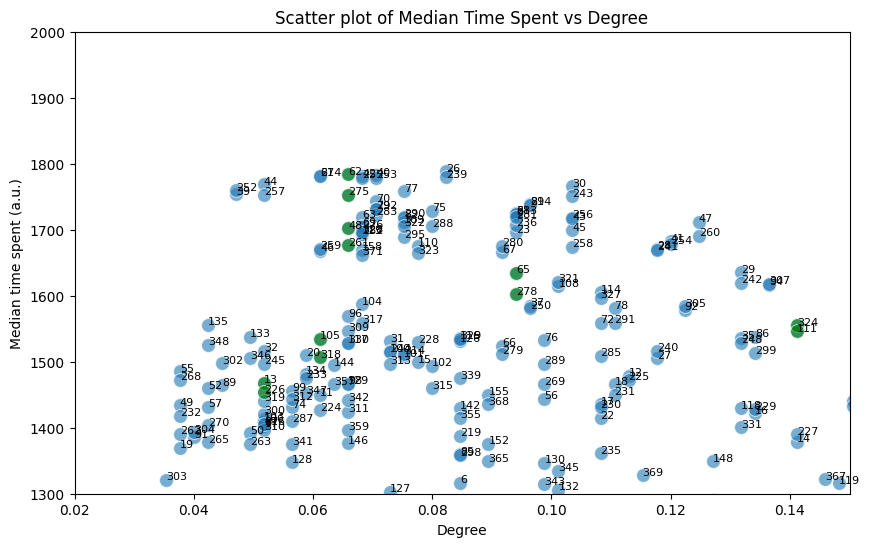

In [16]:
analyse.plot_node_color(random_nodes, "g", G, df_nc)

# Zoomed in for better visibility
plt.xlim((0.02, 0.15))
plt.ylim((1300, 2000))

['../../data/raw/random_nodes/itr_200_1.bz2', '../../data/raw/random_nodes/itr_200_2.bz2', '../../data/raw/random_nodes/itr_200_3.bz2', '../../data/raw/random_nodes/itr_200_4.bz2', '../../data/raw/random_nodes/itr_200_5.bz2', '../../data/raw/random_nodes/itr_200_62.bz2', '../../data/raw/random_nodes/itr_200_fn.bz2']
Number of transitions / 100 iteration [1, 72, 128]
Number of transition [0, 1, 2, 3, 4, 6, 7, 8, 9, 10, 12, 17, 18, 19, 21, 22, 24, 26, 29, 31, 32, 34, 35, 36, 39, 40, 41, 42, 43, 46, 48, 49, 50, 51, 53, 55, 56, 60, 62, 65, 71, 72, 73, 76, 77, 78, 80, 81, 82, 84, 87, 89, 91, 98, 100, 105, 106, 109, 110, 112, 114, 117, 119, 120, 121, 123, 125, 127, 129, 131, 132, 133, 134, 135, 136, 137, 138, 139, 142, 143, 146, 149, 150, 152, 153, 155, 156, 157, 158, 160, 161, 163, 164, 165, 169, 170, 173, 176, 179, 180, 182, 185, 189, 192, 193, 194]
Number of transition with more than one transition or a fall back [2, 4, 7, 9, 18, 19, 21, 22, 26, 31, 34, 41, 42, 43, 51, 53, 55, 56, 60, 72,

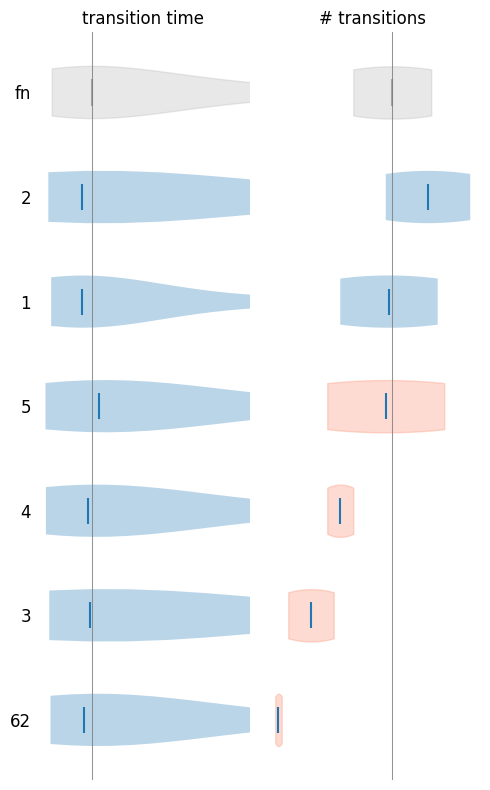

In [18]:
data_folder = Path("../../data/raw/random_nodes/")
files = glob.glob(str(data_folder / "itr_200*.bz2"))

print(files)
x = []
itr_count = []

# Initialize a dictionary to store parameter lists
transition_count = {}  # to store number of transitions
transition_time = {}  # to store transition times

for f in files:

    # Extract the part of the filename after the underscore
    file_stem = Path(f).stem  # e.g., "itr_bla"
    name_suffix = file_stem.split("_")[2]
    # x.append(name_suffix)
    df_d = pd.read_pickle(f, compression="bz2")

    # compute parameters
    params = analyse.compute_param(df_d, 0.05)

    # store lists in dictionary
    transition_count[f"{name_suffix}"] = params["tran_per"]
    transition_time[f"{name_suffix}"] = params["trans"]

node_order = np.array(["fn", "1", "2", "3", "4", "5", "62"])
non = np.r_[np.argsort([transition_count[k][-1] / 1000 for k in node_order[1:]]) + 1, 0]
non


f, (ax1, ax2) = plt.subplots(1, 2, figsize=(5, 8), sharey=True)

_artists = ax1.violinplot(
    [transition_time[k] for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True,
)
ax1.set_yticks(np.arange(1, len(node_order) + 1))
ax1.set_yticklabels(node_order[non], fontsize=12)
_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax1.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax1.set_xticks([])
ax1.set_xlim(20, 100)
ax1.tick_params(axis="both", which="both", length=0)
ax1.set_title("transition time")
ax1.axvline(np.median(transition_time["fn"]), c=cm.Greys(0.6, 0.8), lw=0.75)

_artists = ax2.violinplot(
    [np.diff(np.array(transition_count[k])) for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True,
)
# ax3.set_yticks(np.arange(1, len(node_order)+1))
# ax3.set_yticklabels(node_order)
_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
for i in range(4):
    _artists["bodies"][i].set_color(cm.Reds(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax2.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax2.set_xticks([])
# ax3.set_xlim(80, 500)
ax2.tick_params(axis="both", which="both", length=0)
ax2.set_title("# transitions")
ax2.axvline(np.median(np.diff(transition_count["fn"])), c=cm.Greys(0.6, 0.8), lw=0.75)


f.subplots_adjust(wspace=0.8)
f.tight_layout()

# Control Nodes



### Checking parameters for these control nodes

Node 0: FN  
Node 1: 251,38  
Node 2: 71,284  
Node 3: 1, 214  
Node 4: 149, 362


In [10]:
control_nodes = [251, 38, 71, 284, 1, 214, 149, 362]

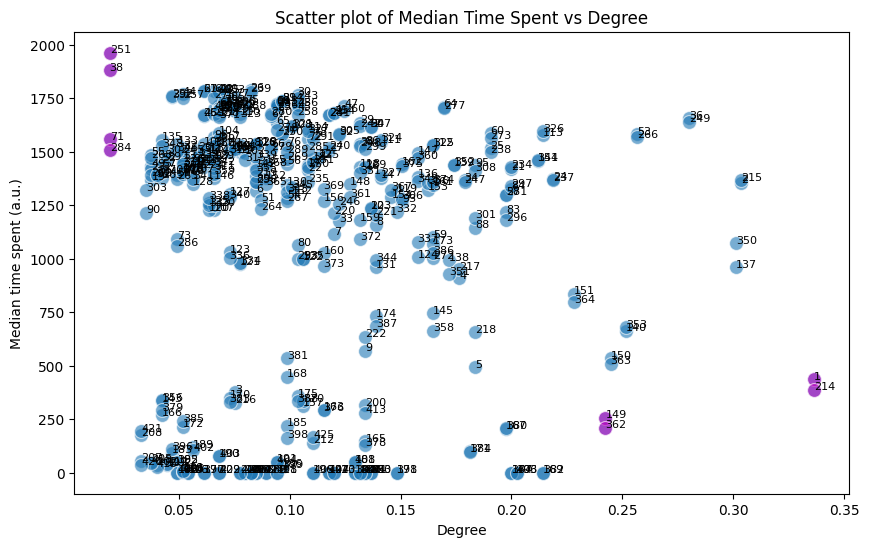

In [11]:
analyse.plot_node_color(control_nodes, "m", G, df_nc)

## Plot parameters for control nodes

In [12]:
data_folder = Path("../../data/raw/check_control/")
files = glob.glob(str(data_folder / "itr_200*.bz2"))

print(files)
x = []
itr_count = []

# Initialize a dictionary to store parameter lists
transition_count = {}  # to store number of transitions
transition_time = {}  # to store transition times

for f in files:

    # Extract the part of the filename after the underscore
    file_stem = Path(f).stem  # e.g., "itr_bla"
    name_suffix = file_stem.split("_")[2]
    # x.append(name_suffix)
    df_d = pd.read_pickle(f, compression="bz2")

    # compute parameters
    params = analyse.compute_param(df_d, 0.05)

    # store lists in dictionary
    transition_count[f"{name_suffix}"] = params["tran_per"]
    transition_time[f"{name_suffix}"] = params["trans"]

['../../data/raw/check_control/itr_200_1.bz2', '../../data/raw/check_control/itr_200_2.bz2', '../../data/raw/check_control/itr_200_3.bz2', '../../data/raw/check_control/itr_200_4.bz2', '../../data/raw/check_control/itr_200_fn.bz2']
Number of transitions / 100 iteration [5, 56, 107]
Number of transition [0, 2, 4, 5, 6, 7, 8, 11, 12, 13, 15, 18, 19, 21, 25, 27, 28, 29, 38, 39, 40, 42, 44, 48, 51, 52, 53, 58, 60, 62, 67, 69, 73, 74, 78, 79, 81, 84, 90, 91, 92, 93, 96, 97, 98, 99, 102, 103, 107, 109, 111, 113, 115, 116, 123, 124, 125, 127, 130, 131, 132, 133, 136, 137, 139, 140, 142, 145, 148, 149, 159, 160, 161, 165, 166, 169, 177, 178, 181, 182, 183, 185, 187, 189, 190, 191, 192, 194, 196, 198, 199]
Number of transition with more than one transition or a fall back [0, 12, 21, 29, 39, 40, 42, 44, 53, 74, 78, 79, 91, 103, 116, 124, 133, 136, 137, 140, 149, 159, 160, 161, 166, 177, 178, 181, 198]
Number of transitions / 100 iteration [1, 78, 132]
Number of transition [0, 1, 2, 5, 6, 7, 9, 1

In [13]:
node_order = np.array(["fn", "1", "2", "3", "4"])
non = np.r_[np.argsort([transition_count[k][-1] / 1000 for k in node_order[1:]]) + 1, 0]
non

array([3, 4, 1, 2, 0])

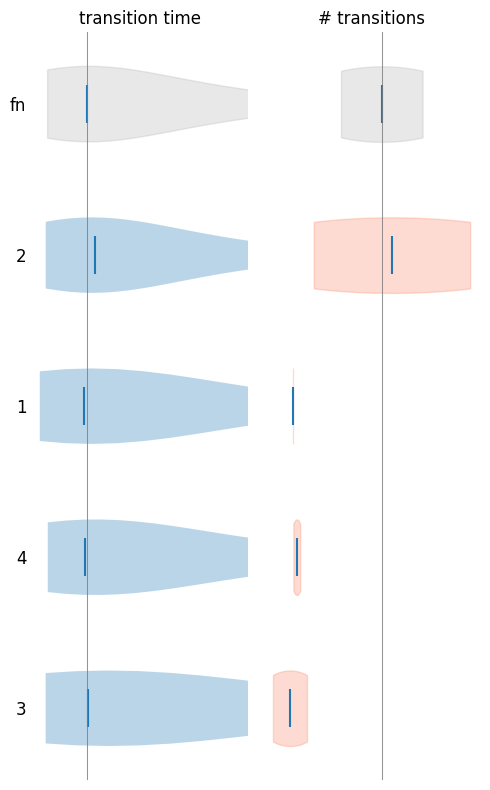

In [16]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(5, 8), sharey=True)

_artists = ax1.violinplot(
    [transition_time[k] for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True,
)
ax1.set_yticks(np.arange(1, len(node_order) + 1))
ax1.set_yticklabels(node_order[non], fontsize=12)
_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax1.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax1.set_xticks([])
ax1.set_xlim(20, 100)
ax1.tick_params(axis="both", which="both", length=0)
ax1.set_title("transition time")
ax1.axvline(np.median(transition_time["fn"]), c=cm.Greys(0.6, 0.8), lw=0.75)

_artists = ax2.violinplot(
    [np.diff(np.array(transition_count[k])) for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True,
)
# ax3.set_yticks(np.arange(1, len(node_order)+1))
# ax3.set_yticklabels(node_order)
_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
for i in range(4):
    _artists["bodies"][i].set_color(cm.Reds(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax2.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax2.set_xticks([])
# ax3.set_xlim(80, 500)
ax2.tick_params(axis="both", which="both", length=0)
ax2.set_title("# transitions")
ax2.axvline(np.median(np.diff(transition_count["fn"])), c=cm.Greys(0.6, 0.8), lw=0.75)


f.subplots_adjust(wspace=0.8)
f.tight_layout()

### Plot TOE for control nodes

In [6]:
data_folder = Path("../../data/raw/check_control/")
files = glob.glob(str(data_folder / "nc_200*.bz2"))

print(files)

label = ["251,38", "71,284", "1, 214", "149, 362"]

toe = []
for f in files:

    # Extract the part of the filename after the underscore
    file_stem = Path(f).stem  # e.g., "itr_bla"
    name_suffix = file_stem.split("_")[2]
    # x.append(name_suffix)
    df_nc = pd.read_pickle(f, compression="bz2")
    df_r = df_nc.reset_index(drop=True)
    mean_toe = analyse.avg_toe(df_r)
    toe.append(mean_toe)

# Sorting by communities
desired_order = list(reader.get_communities()["des_order"])
df_toe = pd.DataFrame(toe, index=label).T

# very powerful, whenever you concat any node data to community map, it automatically arranges in that order
toe_plot_data = pd.concat(
    [reader.get_communities()["comm_map"].to_frame(), df_toe], axis=1
)

# change this if
toe_plot_data.columns = ["community", "251,38", "71,284", "1, 214", "149, 362"]

['../../data/raw/check_control/nc_200_1.bz2', '../../data/raw/check_control/nc_200_2.bz2', '../../data/raw/check_control/nc_200_3.bz2', '../../data/raw/check_control/nc_200_4.bz2']


Text(0.5, 0.9, 'Time of Entry of control nodes (grouped by community)')

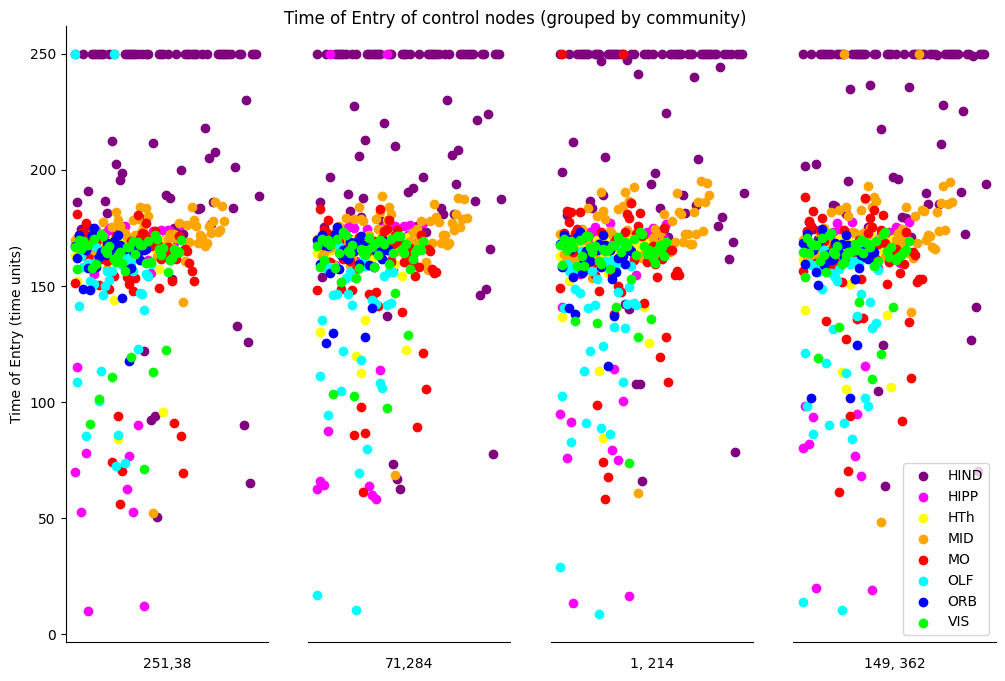

In [8]:
# getting communities data for x axis plot
l = reader.get_communities()["comm_val"]
l = l.to_dict()

comm = ["MO", "VIS", "ORB", "HTh", "OLF", "HIPP", "MID", "HIND"]

node_c_avi = [
    "#00FFFF",
    "#0000FF",
    "#ADD8E6",
    "#0000CD",
    "#808000",
    "#008000",
    "#006400",
    "#8B4513",
]

fig, ax = plt.subplots(1, 4, sharex=True, sharey=True, figsize=(12, 8))

label = ["214,1", "215,2", "249,36", "137,350", "53,266"]

node_c_nim = [
    "#FF0000",
    "#00FF00",
    "#0000FF",
    "#FFFF00",
    "#00FFFF",
    "#FF00FF",
    "#FFA500",
    "#800080",
]
col = dict(zip(comm, node_c_nim))
grouped = toe_plot_data.groupby("community")
for community, group in grouped:
    ax[0].scatter(
        range(0, l[community]),
        group[toe_plot_data.columns[1]] * 0.05,
        color=col[community],
        label=community,
    )
    ax[0].set_ylabel("Time of Entry (time units)")
    # ax[0].spines[["left", "right", "top", "bottom"]].set_visible(False)
    ax[0].set_xticks([50])
    ax[0].set_xticklabels([])
    ax[0].set_xlabel(toe_plot_data.columns[1])
    # ax[0].tick_params(axis="both", which="both", length=0)

    ax[1].scatter(
        range(0, l[community]),
        group[toe_plot_data.columns[2]] * 0.05,
        color=col[community],
        label=community,
    )
    ax[1].set_xticks([50])
    ax[1].set_xticklabels([])
    ax[1].set_xlabel(toe_plot_data.columns[2])

    ax[2].scatter(
        range(0, l[community]),
        group[toe_plot_data.columns[3]] * 0.05,
        color=col[community],
        label=community,
    )
    ax[2].set_xticks([50])
    ax[2].set_xticklabels([])
    ax[2].set_xlabel(toe_plot_data.columns[3])

    ax[3].scatter(
        range(0, l[community]),
        group[toe_plot_data.columns[4]] * 0.05,
        color=col[community],
        label=community,
    )
    ax[3].set_xticks([50])
    ax[3].set_xticklabels([])
    ax[3].set_xlabel(toe_plot_data.columns[4])


# Remove outlines: Remove top/right spines from each subplot and hide most of the x-axis spines
for i, a in enumerate(ax):
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)

    # Hide the bottom spine for all subplots except the first one:
    if i != 0:
        a.spines["bottom"].set_visible(False)
        a.tick_params(bottom=False)  # Remove tick marks on the x-axis
        a.spines["left"].set_visible(False)
        a.tick_params(left=False)
    else:
        a.spines["bottom"].set_visible(True)
        a.tick_params(bottom=True)

    # Ensure the left spine (y-axis) is visible:
    # a.spines['left'].set_visible(True)
    a.spines["bottom"].set_visible(True)
    a.tick_params(bottom=False)


plt.legend()
plt.suptitle("Time of Entry of control nodes (grouped by community)", x=0.5, y=0.9)